# ⚽ Football Expected Goals (XG) Analysis

Comprehensive AI-powered football analytics using **real World Cup 2018 data** from StatsBomb.

**Features:**
- XGBoost machine learning model
- Real match data (1,706 shots)
- Team & player analysis
- Interactive predictions

## 📦 Installation & Setup

In [1]:
# Install packages
!pip install numpy pandas scikit-learn xgboost matplotlib seaborn scipy joblib statsbombpy -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
import xgboost as xgb
from statsbombpy import sb
import math

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
print("✅ Packages loaded!")

✅ Packages loaded!


## 🔧 Load Pre-processed Data

We already have real World Cup 2018 data ready!

In [3]:
from pathlib import Path

# Load your existing CSV (fallback) so the notebook always runs
csv_candidates = [
    Path("data/real_shot_data_with_xg.csv"),
    Path("real_shot_data_with_xg.csv"),
]

df_base = None
for p in csv_candidates:
    if p.exists():
        df_base = pd.read_csv(p)
        break

if df_base is None:
    raise FileNotFoundError(
        "Could not find `real_shot_data_with_xg.csv` in either `data/` or project root."
    )

print(f"Loaded {len(df_base)} shots from CSV: {p}")
print(f"Goals: {df_base['goal'].sum()} ({df_base['goal'].mean():.1%} conversion rate)")
print(f"Dataset shape: {df_base.shape}")

# Default working dataframe (we'll optionally replace it with more StatsBomb shots below)
df = df_base.copy()

df.head(10)

Loaded 1706 shots from CSV: real_shot_data_with_xg.csv
Goals: 183 (10.7% conversion rate)
Dataset shape: (1706, 17)


,x,y,shot_type,body_part,play_pattern,under_pressure,num_defenders_nearby,assist_type,game_situation,goal,player,team,outcome,match_date,distance_to_goal,angle_to_goal,xg
0,115.0,18.0,0,0,2,1,4,1,1,0,Ashley Young,England,Saved,2018-07-03,18.867962,0.210493,0.017157
1,112.0,54.0,0,0,2,1,4,1,0,0,Raheem Sterling,England,Blocked,2018-07-03,21.189620,0.117092,0.068839
2,98.0,37.0,0,0,1,1,4,1,0,0,Raheem Sterling,England,Blocked,2018-07-03,7.615773,0.854521,0.013776
3,119.0,36.0,2,1,2,1,4,1,0,0,Harry Kane,England,Off T,2018-07-03,14.142136,5.780969,0.167182
4,97.0,56.0,0,0,0,1,4,1,0,0,Juan Guillermo Cuadrado Bello,Colombia,Blocked,2018-07-03,23.409400,0.109104,0.011086
5,90.0,18.0,1,0,0,1,4,1,0,0,Johan Andrés Mojica Palacio,Colombia,Off T,2018-07-03,21.931712,0.230636,0.001788
6,101.0,46.0,1,0,0,1,4,1,0,0,Raheem Sterling,England,Blocked,2018-07-03,12.649111,0.197127,0.005317
7,92.0,49.0,1,0,0,1,4,1,0,0,Juan Fernando Quintero Paniagua,Colombia,Off T,2018-07-03,19.849433,0.245001,0.002251
8,99.0,31.0,0,0,2,1,4,1,1,0,Kieran Trippier,England,Off T,2018-07-03,6.708204,0.947043,0.040269
9,94.0,59.0,0,0,0,1,4,1,0,0,Harry Kane,England,Off T,2018-07-03,27.313001,0.109470,0.040678


## 📊 Data Exploration

In [4]:
print("Dataset Statistics:\n")
print(f"Total Shots: {len(df)}")
print(f"Total Goals: {df['goal'].sum()}")
print(f"Conversion Rate: {df['goal'].mean():.2%}")
print(
    f"Distance: Mean={df['distance_to_goal'].mean():.1f}, "
    f"Range={df['distance_to_goal'].min():.1f}-{df['distance_to_goal'].max():.1f}"
)

# Top scorers
print("\n🏆 Top 10 Scorers:")
top_scorers = df[df["goal"] == 1].groupby("player").size().sort_values(ascending=False).head(10)
for p, g in top_scorers.items():
    print(f"  {p}: {g} goals")

Dataset Statistics:

Total Shots: 1706
Total Goals: 183
Conversion Rate: 10.73%
Distance: Mean=13.3, Range=1.0-46.0

🏆 Top 10 Scorers:
  Harry Kane: 7 goals
  Denis Cheryshev: 5 goals
  Romelu Lukaku Menama: 4 goals
  Antoine Griezmann: 4 goals
  Luka Modrić: 4 goals
  Kylian Mbappé Lottin: 4 goals
  Cristiano Ronaldo dos Santos Aveiro: 4 goals
  Diego da Silva Costa: 3 goals
  Ivan Perišić: 3 goals
  Ivan Rakitić: 3 goals


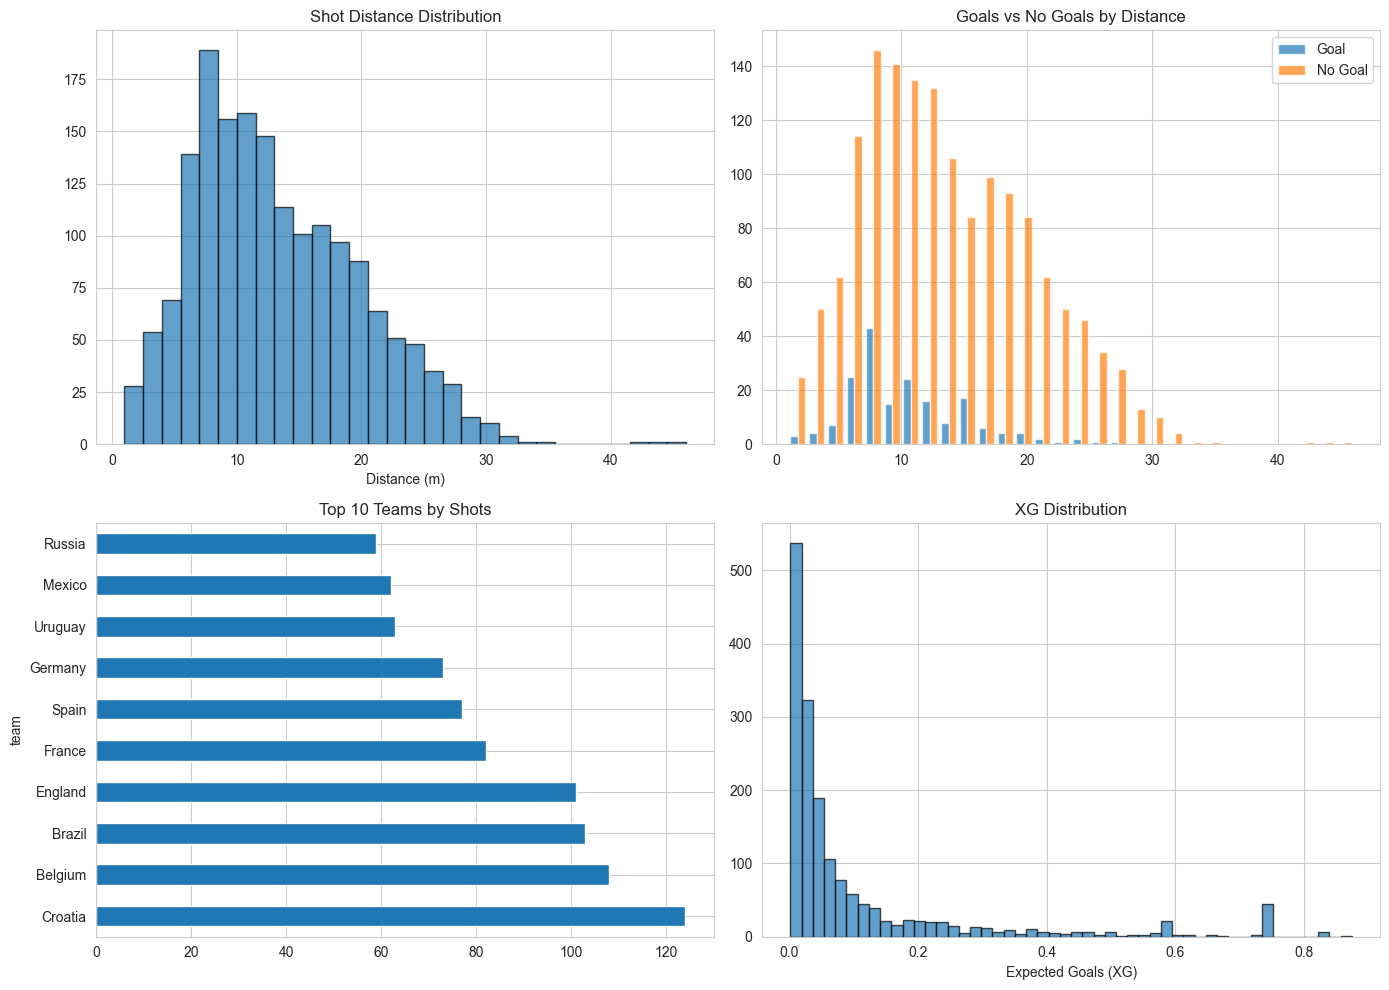

In [5]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distance distribution
axes[0,0].hist(df["distance_to_goal"], bins=30, alpha=0.7, edgecolor="black")
axes[0,0].set_title("Shot Distance Distribution")
axes[0,0].set_xlabel("Distance (m)")

# Goals vs No Goals
goals = df[df["goal"]==1]["distance_to_goal"]
no_goals = df[df["goal"]==0]["distance_to_goal"]
axes[0,1].hist([goals, no_goals], bins=30, label=["Goal", "No Goal"], alpha=0.7)
axes[0,1].set_title("Goals vs No Goals by Distance")
axes[0,1].legend()

# Top teams
team_shots = df["team"].value_counts().head(10)
team_shots.plot(kind="barh", ax=axes[1,0])
axes[1,0].set_title("Top 10 Teams by Shots")

# XG distribution
axes[1,1].hist(df["xg"], bins=50, alpha=0.7, edgecolor="black")
axes[1,1].set_title("XG Distribution")
axes[1,1].set_xlabel("Expected Goals (XG)")

plt.tight_layout()
plt.show()

## 🤖 Train XG Model

In [6]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss, average_precision_score

# ----------------------------
# Build a better training set from StatsBomb Open Data
# (includes shot freeze-frame -> defenders/GK features)
# ----------------------------
USE_STATSBOMB_OPEN_DATA = True

# A small-but-valuable set of open competitions (easy wins)
COMP_SEASONS = [
    (43, 3, "WC 2018"),
    (43, 106, "WC 2022"),
    (55, 43, "Euro 2020"),
    (223, 282, "Copa America 2024"),
    (11, 90, "La Liga 2020/21 (partial)"),
    (11, 42, "La Liga 2019/20 (partial)"),
    (7, 108, "Ligue 1 2021/22 (partial)"),
    (7, 235, "Ligue 1 2022/23 (partial)"),
    (9, 281, "Bundesliga 2023/24 (partial)"),
]

GOAL_X = 120.0
GOAL_Y = 40.0
LEFT_POST_Y = 36.0
RIGHT_POST_Y = 44.0


def _shot_distance_and_angle(x: float, y: float):
    # StatsBomb coordinate system is 120x80. Goal is at (120, 40).
    dx = GOAL_X - x
    dy = GOAL_Y - y
    dist = math.sqrt(dx * dx + dy * dy)

    # Angle between lines to each post
    a1 = math.atan2(RIGHT_POST_Y - y, GOAL_X - x)
    a2 = math.atan2(LEFT_POST_Y - y, GOAL_X - x)
    ang = abs(a1 - a2)
    return dist, ang


def _lane_bounds_at_x(shooter_x, shooter_y, x):
    # Linear interpolation for y on the rays to each post
    if x <= shooter_x:
        return None
    t = (x - shooter_x) / (GOAL_X - shooter_x) if GOAL_X != shooter_x else None
    if t is None:
        return None
    y_left = shooter_y + t * (LEFT_POST_Y - shooter_y)
    y_right = shooter_y + t * (RIGHT_POST_Y - shooter_y)
    return (min(y_left, y_right), max(y_left, y_right))


def _freeze_frame_features(shooter_x, shooter_y, freeze_frame):
    # freeze_frame is a list of players (teammate True/False) with locations.
    if not isinstance(freeze_frame, list) or len(freeze_frame) == 0:
        return {
            "gk_distance": np.nan,
            "nearest_defender_distance": np.nan,
            "defenders_within_1": 0,
            "defenders_within_2": 0,
            "defenders_within_3": 0,
            "defenders_in_lane": 0,
        }

    defenders = [p for p in freeze_frame if p.get("teammate") is False and isinstance(p.get("location"), list)]

    # identify goalkeeper (if present)
    gk = None
    for p in defenders:
        pos = (p.get("position") or {}).get("name")
        if pos == "Goalkeeper":
            gk = p
            break

    def _dist(loc):
        return math.sqrt((loc[0] - shooter_x) ** 2 + (loc[1] - shooter_y) ** 2)

    gk_dist = np.nan
    if gk is not None:
        gk_dist = _dist(gk["location"])

    defenders_wo_gk = [p for p in defenders if p is not gk]
    dists = [_dist(p["location"]) for p in defenders_wo_gk]

    nearest_def = float(min(dists)) if len(dists) else np.nan
    within_1 = int(sum(d <= 1.0 for d in dists))
    within_2 = int(sum(d <= 2.0 for d in dists))
    within_3 = int(sum(d <= 3.0 for d in dists))

    in_lane = 0
    for p in defenders_wo_gk:
        x, y = p["location"]
        if x <= shooter_x or x > GOAL_X:
            continue
        bounds = _lane_bounds_at_x(shooter_x, shooter_y, x)
        if bounds is None:
            continue
        y_low, y_high = bounds
        if y_low <= y <= y_high:
            in_lane += 1

    return {
        "gk_distance": gk_dist,
        "nearest_defender_distance": nearest_def,
        "defenders_within_1": within_1,
        "defenders_within_2": within_2,
        "defenders_within_3": within_3,
        "defenders_in_lane": int(in_lane),
    }


def _load_statsbomb_shots(comp_seasons):
    rows = []

    for comp_id, season_id, label in comp_seasons:
        matches = sb.matches(competition_id=comp_id, season_id=season_id)
        match_ids = matches["match_id"].astype(int).tolist()
        print(f"Fetching {label}: {len(match_ids)} matches")

        for match_id in match_ids:
            ev = sb.events(match_id=match_id)
            shots = ev[ev["type"] == "Shot"].copy()
            if len(shots) == 0:
                continue

            # Required columns exist in open data; some may be missing in older competitions.
            for _, r in shots.iterrows():
                loc = r.get("location")
                if not isinstance(loc, list) or len(loc) < 2:
                    continue
                x, y = float(loc[0]), float(loc[1])

                dist, ang = _shot_distance_and_angle(x, y)
                ff = r.get("shot_freeze_frame")
                ff_feats = _freeze_frame_features(x, y, ff)

                shot_type = r.get("shot_type")
                body_part = r.get("shot_body_part")
                technique = r.get("shot_technique")

                outcome = r.get("shot_outcome")
                goal = int(outcome == "Goal")

                statsbomb_xg = r.get("shot_statsbomb_xg")

                rows.append({
                    "match_id": int(r.get("match_id")) if pd.notna(r.get("match_id")) else int(match_id),
                    "competition_id": int(comp_id),
                    "season_id": int(season_id),
                    "match_date": r.get("timestamp"),
                    "team": r.get("team"),
                    "player": r.get("player"),
                    "x": x,
                    "y": y,
                    "distance_to_goal": dist,
                    "angle_to_goal": ang,
                    "under_pressure": int(bool(r.get("under_pressure"))) if pd.notna(r.get("under_pressure")) else 0,
                    "play_pattern": r.get("play_pattern"),
                    "shot_type": shot_type,
                    "body_part": body_part,
                    "shot_technique": technique,
                    "shot_first_time": int(bool(r.get("shot_first_time"))) if pd.notna(r.get("shot_first_time")) else 0,
                    "shot_open_goal": int(bool(r.get("shot_open_goal"))) if pd.notna(r.get("shot_open_goal")) else 0,
                    "shot_follows_dribble": int(bool(r.get("shot_follows_dribble"))) if pd.notna(r.get("shot_follows_dribble")) else 0,
                    "shot_deflected": int(bool(r.get("shot_deflected"))) if pd.notna(r.get("shot_deflected")) else 0,
                    "statsbomb_xg": float(statsbomb_xg) if pd.notna(statsbomb_xg) else np.nan,
                    "goal": goal,
                    **ff_feats,
                    "is_penalty": int(shot_type == "Penalty"),
                    "is_free_kick_shot": int(shot_type == "Free Kick"),
                })

    df_shots = pd.DataFrame(rows)
    return df_shots


if USE_STATSBOMB_OPEN_DATA:
    # Cache for faster reruns
    out_dir = Path("data")
    out_dir.mkdir(exist_ok=True)
    out_path = out_dir / "statsbomb_open_shots.csv"

    if out_path.exists():
        df = pd.read_csv(out_path)
        print(f"✅ Loaded cached StatsBomb shots: {len(df):,} ({out_path})")
    else:
        df = _load_statsbomb_shots(COMP_SEASONS)
        print(f"\n✅ StatsBomb Open Data shots loaded: {len(df):,}")
        df.to_csv(out_path, index=False)
        print(f"Saved: {out_path}")
else:
    # Use the CSV you already have
    df = df_base.copy()

# Backwards-compat for the rest of the notebook
if "statsbomb_xg" in df.columns and "xg" not in df.columns:
    df["xg"] = df["statsbomb_xg"]

# If we ever fall back to a CSV without match_id, make a safe grouping key
if "match_id" not in df.columns:
    df["match_id"] = np.arange(len(df))

# ----------------------------
# Train/test split (grouped by match to reduce leakage)
# ----------------------------

y = df["goal"].astype(int)

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss.split(df, y, groups=df["match_id"]))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_temp = df.iloc[temp_idx].reset_index(drop=True)

# split temp into val/test

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss2.split(df_temp, df_temp["goal"], groups=df_temp["match_id"]))

df_val = df_temp.iloc[val_idx].reset_index(drop=True)
df_test = df_temp.iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

# Features
num_cols = [
    "x",
    "y",
    "distance_to_goal",
    "angle_to_goal",
    "gk_distance",
    "nearest_defender_distance",
    "defenders_within_1",
    "defenders_within_2",
    "defenders_within_3",
    "defenders_in_lane",
]

bool_cols = [
    "under_pressure",
    "shot_first_time",
    "shot_open_goal",
    "shot_follows_dribble",
    "shot_deflected",
    "is_penalty",
    "is_free_kick_shot",
]

cat_cols = [
    "shot_type",
    "body_part",
    "shot_technique",
    "play_pattern",
]

feature_cols = num_cols + bool_cols + cat_cols

X_train_df = df_train[feature_cols]
y_train = df_train["goal"].astype(int)
X_val_df = df_val[feature_cols]
y_val = df_val["goal"].astype(int)
X_test_df = df_test[feature_cols]
y_test = df_test["goal"].astype(int)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols + bool_cols),
    ],
    remainder="drop",
)

X_train = preprocess.fit_transform(X_train_df)
X_val = preprocess.transform(X_val_df)
X_test = preprocess.transform(X_test_df)

print("✅ Data prepared with proper categorical encoding")

Fetching WC 2018: 64 matches
Fetching WC 2022: 64 matches
Fetching Euro 2020: 51 matches
Fetching Copa America 2024: 32 matches
Fetching La Liga 2020/21 (partial): 35 matches
Fetching La Liga 2019/20 (partial): 33 matches
Fetching Ligue 1 2021/22 (partial): 26 matches
Fetching Ligue 1 2022/23 (partial): 32 matches
Fetching Bundesliga 2023/24 (partial): 34 matches

✅ StatsBomb Open Data shots loaded: 9,318
Saved: data/statsbomb_open_shots.csv
Train: 6,484 | Val: 1,454 | Test: 1,380
✅ Data prepared with proper categorical encoding


In [12]:
# Train model (better defaults for probabilistic prediction)
model = xgb.XGBClassifier(
    n_estimators=2500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    early_stopping_rounds=50,
    random_state=42,
    tree_method="hist",
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f"✅ Model trained! Best iteration: {model.best_iteration}")

✅ Model trained! Best iteration: 194


In [13]:
from sklearn.metrics import accuracy_score

# Evaluate (probability-quality metrics matter most for xG)
y_pred = (model.predict_proba(X_test)[:, 1] >= 0.5).astype(int)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy@0.5": accuracy_score(y_test, y_pred),
    "AUC-ROC": roc_auc_score(y_test, y_proba),
    "PR-AUC": average_precision_score(y_test, y_proba),
    "LogLoss": log_loss(y_test, y_proba),
    "Brier": brier_score_loss(y_test, y_proba),
}

print("\n✅ Test metrics (our model)")
for k, v in metrics.items():
    print(f"{k:12s}: {v:.4f}")

# Compare against StatsBomb's own xG (strong baseline)
if "statsbomb_xg" in df_test.columns:
    base = df_test["statsbomb_xg"].astype(float)
    ok = base.notna()
    if ok.sum() > 0:
        base_metrics = {
            "AUC-ROC": roc_auc_score(y_test[ok], base[ok]),
            "PR-AUC": average_precision_score(y_test[ok], base[ok]),
            "LogLoss": log_loss(y_test[ok], base[ok]),
            "Brier": brier_score_loss(y_test[ok], base[ok]),
        }
        print("\n📏 Baseline: StatsBomb xG on same test shots")
        for k, v in base_metrics.items():
            print(f"{k:12s}: {v:.4f}")

# Feature importance (top gains) with readable feature names
try:
    feature_names = preprocess.get_feature_names_out()
    gain = model.get_booster().get_score(importance_type="gain")
    # gain keys look like 'f123'
    items = []
    for k, v in gain.items():
        if k.startswith("f"):
            idx = int(k[1:])
            if 0 <= idx < len(feature_names):
                items.append((feature_names[idx], v))
    feature_imp = pd.DataFrame(items, columns=["feature", "gain"]).sort_values("gain", ascending=False)
    print("\nTop 15 features by gain:")
    try:
        from IPython.display import display
        display(feature_imp.head(15))
    except Exception:
        print(feature_imp.head(15).to_string(index=False))
except Exception as e:
    print("\n(Feature importance names unavailable)", e)


✅ Test metrics (our model)
Accuracy@0.5: 0.8804
AUC-ROC     : 0.7831
PR-AUC      : 0.4264
LogLoss     : 0.3268
Brier       : 0.0959

📏 Baseline: StatsBomb xG on same test shots
AUC-ROC     : 0.8052
PR-AUC      : 0.4729
LogLoss     : 0.3124
Brier       : 0.0916

Top 15 features by gain:


,feature,gain
1,cat__shot_type_Penalty,242.007919
0,cat__shot_type_Open Play,73.815910
19,num__gk_distance,25.626011
2,cat__body_part_Head,17.510323
22,num__defenders_within_2,14.011319
27,num__shot_open_goal,11.624515
13,cat__play_pattern_Other,10.045817
18,num__angle_to_goal,9.398856
24,num__defenders_in_lane,8.796384
20,num__nearest_defender_distance,7.599594


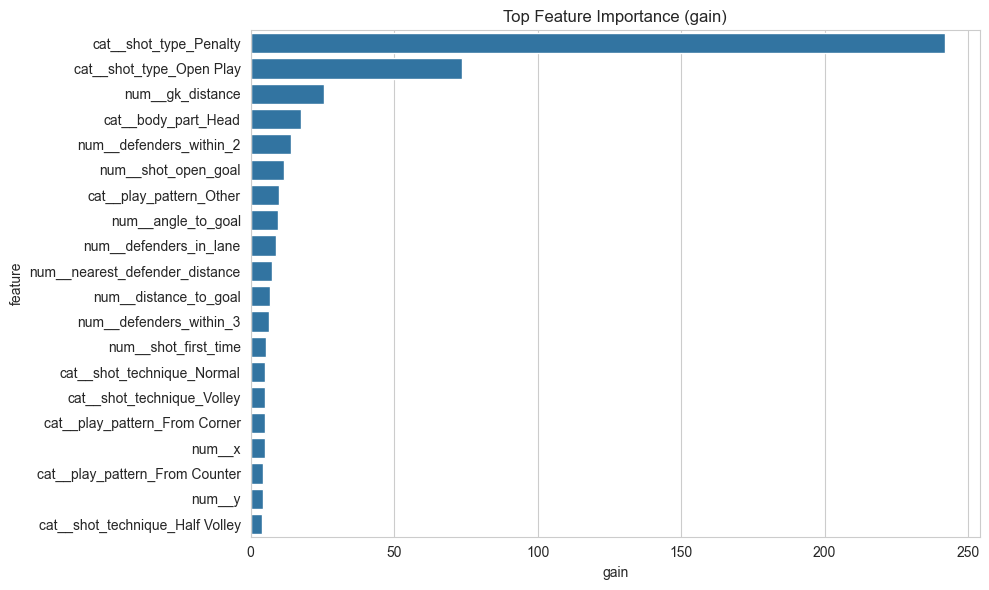

In [14]:
# Plot feature importance (if available)
if "feature_imp" in globals() and isinstance(feature_imp, pd.DataFrame) and len(feature_imp) > 0:
    plt.figure(figsize=(10, 6))
    top = feature_imp.head(20).copy()
    # handle either 'gain' or old 'importance'
    value_col = "gain" if "gain" in top.columns else ("importance" if "importance" in top.columns else None)
    if value_col is not None:
        sns.barplot(data=top, x=value_col, y="feature")
        plt.title("Top Feature Importance (gain)")
        plt.tight_layout()
        plt.show()
else:
    print("Feature importance not available for plotting.")

## 🏆 Team Analysis

In [15]:
# Team statistics
team_stats = df.groupby("team").agg({"xg": "sum", "goal": "sum", "player": "count"}).round(2)
team_stats.columns = ["Total_XG", "Goals", "Shots"]
team_stats["XG_Diff"] = (team_stats["Goals"] - team_stats["Total_XG"]).round(2)
team_stats = team_stats.sort_values("Goals", ascending=False)

print("Top 15 Teams:\n")
print(team_stats.head(15))

Top 15 Teams:

                     Total_XG  Goals  Shots  XG_Diff
team                                                
Barcelona              127.34    146    973    18.66
Paris Saint-Germain    119.58    136    878    16.42
Bayer Leverkusen        72.70     86    623    13.30
Argentina               42.63     42    256    -0.63
England                 36.51     41    234     4.49
Croatia                 37.54     41    252     3.46
France                  33.96     40    251     6.04
Spain                   40.94     33    254    -7.94
Uruguay                 25.58     27    190     1.42
Brazil                  35.45     25    257   -10.45
Portugal                20.05     25    175     4.95
Switzerland             23.46     24    169     0.54
Belgium                 22.03     24    191     1.97
Colombia                16.59     21    125     4.41
Netherlands             17.74     21    100     3.26


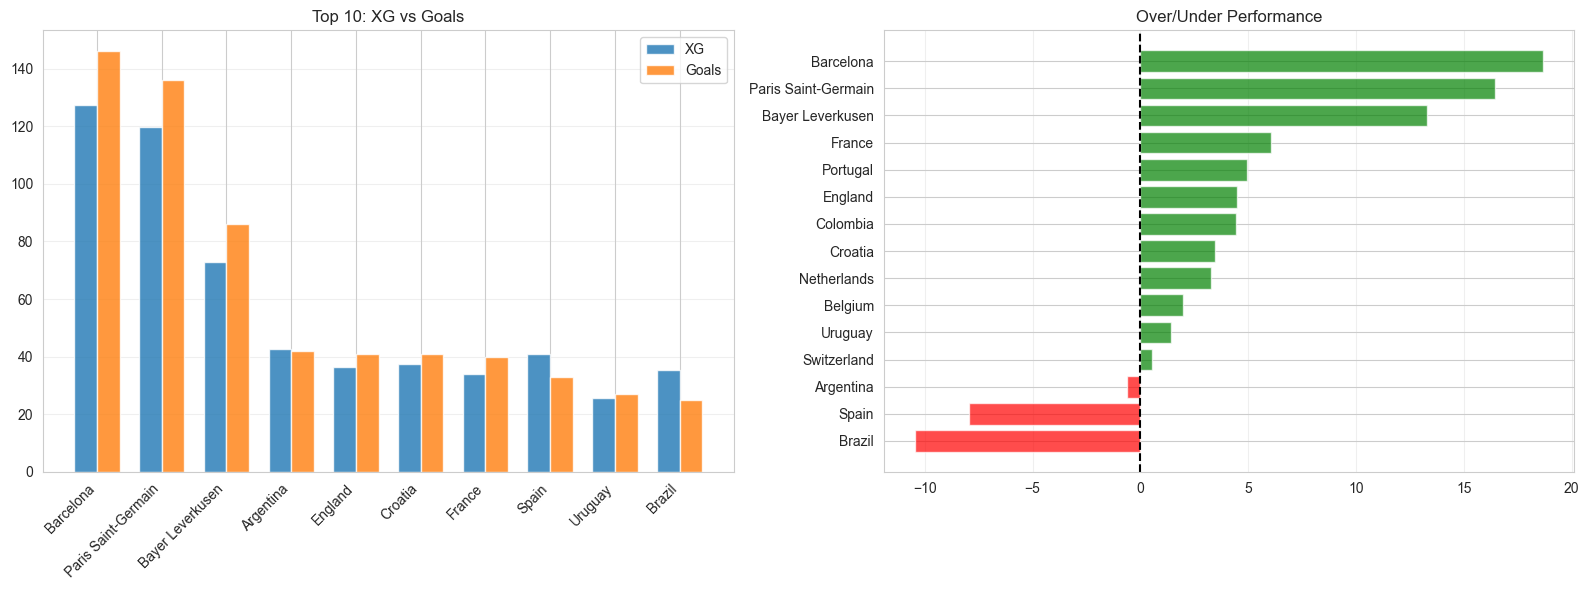

In [16]:
# Visualize teams
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = team_stats.head(10)
x_pos = np.arange(len(top10))
width = 0.35

axes[0].bar(x_pos-width/2, top10["Total_XG"], width, label="XG", alpha=0.8)
axes[0].bar(x_pos+width/2, top10["Goals"], width, label="Goals", alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(top10.index, rotation=45, ha="right")
axes[0].set_title("Top 10: XG vs Goals")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

top15 = team_stats.head(15).sort_values("XG_Diff")
colors = ["red" if x < 0 else "green" for x in top15["XG_Diff"]]
axes[1].barh(top15.index, top15["XG_Diff"], color=colors, alpha=0.7)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Over/Under Performance")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## ⚽ Player Analysis

In [17]:
# Player stats
player_stats = df.groupby("player").agg({"xg": "sum", "goal": "sum", "team": "first"}).round(2)
player_stats.columns = ["Total_XG", "Goals", "Team"]
player_stats["XG_Diff"] = (player_stats["Goals"] - player_stats["Total_XG"]).round(2)
player_stats = player_stats[player_stats["Goals"] > 0].sort_values("Goals", ascending=False)

print("Top 20 Scorers:\n")
print(player_stats.head(20))

Top 20 Scorers:

                                     Total_XG  Goals              Team  \
player                                                                   
Lionel Andrés Messi Cuccittini          75.81     88         Argentina   
Kylian Mbappé Lottin                    47.54     62            France   
Neymar da Silva Santos Junior           23.63     27            Brazil   
Antoine Griezmann                       23.71     24            France   
Luis Alberto Suárez Díaz                14.94     17           Uruguay   
Harry Kane                              12.17     15           England   
Victor Okoh Boniface                    15.97     14  Bayer Leverkusen   
Patrik Schick                            7.70     12    Czech Republic   
Florian Wirtz                            8.47     11  Bayer Leverkusen   
Alejandro Grimaldo García                5.21     10  Bayer Leverkusen   
Cristiano Ronaldo dos Santos Aveiro      9.51     10          Portugal   
Jeremie Frimpong     

In [18]:
# Over/underperformers
qualified = player_stats[player_stats["Goals"] >= 3]

print("🔥 Top Overperformers (min 3 goals):\n")
for p, r in qualified.nlargest(10, "XG_Diff").iterrows():
    print(
        f"  {p:35s} ({r['Team']:12s}): "
        f"{int(r['Goals'])} goals from {r['Total_XG']:.1f} xG ({r['XG_Diff']:+.1f})"
    )

print("\n❄️ Top Underperformers:\n")
for p, r in qualified.nsmallest(5, "XG_Diff").iterrows():
    print(
        f"  {p:35s} ({r['Team']:12s}): "
        f"{int(r['Goals'])} goals from {r['Total_XG']:.1f} xG ({r['XG_Diff']:+.1f})"
    )

🔥 Top Overperformers (min 3 goals):

  Kylian Mbappé Lottin                (France      ): 62 goals from 47.5 xG (+14.5)
  Lionel Andrés Messi Cuccittini      (Argentina   ): 88 goals from 75.8 xG (+12.2)
  Alejandro Grimaldo García           (Bayer Leverkusen): 10 goals from 5.2 xG (+4.8)
  Patrik Schick                       (Czech Republic): 12 goals from 7.7 xG (+4.3)
  Anssumane Fati                      (Barcelona   ): 9 goals from 4.7 xG (+4.3)
  Arturo Erasmo Vidal Pardo           (Barcelona   ): 7 goals from 3.3 xG (+3.7)
  Neymar da Silva Santos Junior       (Brazil      ): 27 goals from 23.6 xG (+3.4)
  Denis Cheryshev                     (Russia      ): 5 goals from 2.1 xG (+2.9)
  Harry Kane                          (England     ): 15 goals from 12.2 xG (+2.8)
  Ivan Perišić                        (Croatia     ): 6 goals from 3.2 xG (+2.8)

❄️ Top Underperformers:

  Martin Braithwaite Christensen      (Denmark     ): 4 goals from 9.3 xG (-5.3)
  Gerard Moreno Balaguero   

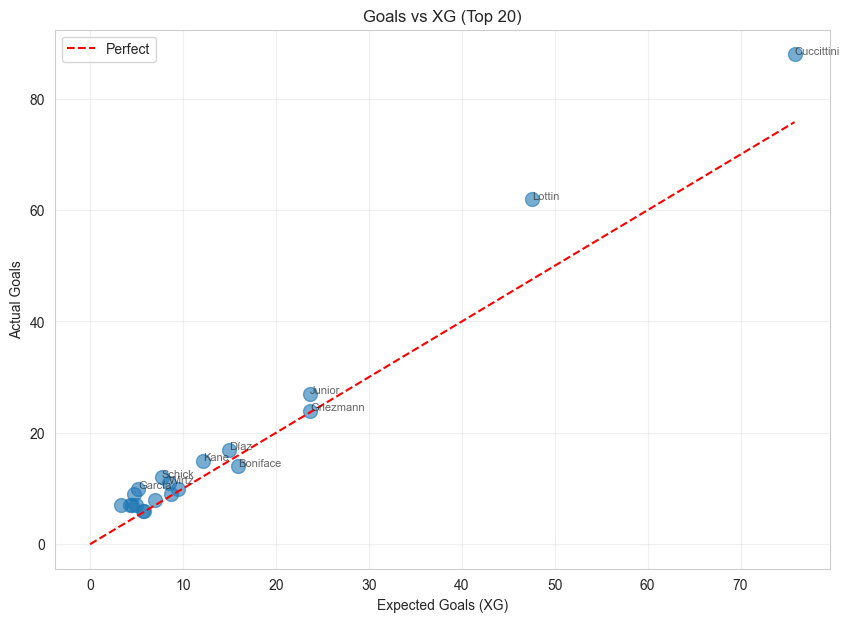

In [19]:
# Scatter plot
top20 = player_stats.head(20)
plt.figure(figsize=(10, 7))
plt.scatter(top20["Total_XG"], top20["Goals"], s=100, alpha=0.6)
plt.plot([0, top20["Total_XG"].max()], [0, top20["Total_XG"].max()], "r--", label="Perfect")
for p, r in top20.head(10).iterrows():
    plt.annotate(p.split()[-1], (r["Total_XG"], r["Goals"]), fontsize=8, alpha=0.7)
plt.xlabel("Expected Goals (XG)")
plt.ylabel("Actual Goals")
plt.title("Goals vs XG (Top 20)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 🎮 Interactive Predictions

In [20]:
def predict_xg_from_location(
    x,
    y,
    shot_type="Open Play",
    body_part="Right Foot",
    shot_technique="Normal",
    play_pattern="Regular Play",
    under_pressure=0,
    gk_distance=np.nan,
    nearest_defender_distance=np.nan,
    defenders_within_1=0,
    defenders_within_2=0,
    defenders_within_3=0,
    defenders_in_lane=0,
    is_penalty=0,
    is_free_kick_shot=0,
):
    # Use the same geometry as training
    dist, ang = _shot_distance_and_angle(float(x), float(y))

    shot = pd.DataFrame([
        {
            "x": float(x),
            "y": float(y),
            "distance_to_goal": dist,
            "angle_to_goal": ang,
            "gk_distance": gk_distance,
            "nearest_defender_distance": nearest_defender_distance,
            "defenders_within_1": int(defenders_within_1),
            "defenders_within_2": int(defenders_within_2),
            "defenders_within_3": int(defenders_within_3),
            "defenders_in_lane": int(defenders_in_lane),
            "under_pressure": int(under_pressure),
            "shot_first_time": 0,
            "shot_open_goal": 0,
            "shot_follows_dribble": 0,
            "shot_deflected": 0,
            "is_penalty": int(is_penalty),
            "is_free_kick_shot": int(is_free_kick_shot),
            "shot_type": shot_type,
            "body_part": body_part,
            "shot_technique": shot_technique,
            "play_pattern": play_pattern,
        }
    ])

    X_row = preprocess.transform(shot[feature_cols])
    return float(model.predict_proba(X_row)[:, 1][0])


print("🎯 Example Predictions (using our improved model):\n")

scenarios = [
    {
        "name": "Close-range central",
        "x": 112,
        "y": 40,
        "shot_type": "Open Play",
        "body_part": "Right Foot",
        "nearest_defender_distance": 2.5,
        "defenders_in_lane": 1,
        "gk_distance": 6.0,
    },
    {
        "name": "Long shot",
        "x": 95,
        "y": 40,
        "shot_type": "Open Play",
        "body_part": "Right Foot",
        "nearest_defender_distance": 1.5,
        "defenders_in_lane": 2,
        "gk_distance": 20.0,
    },
    {
        "name": "Header",
        "x": 110,
        "y": 42,
        "shot_type": "Open Play",
        "body_part": "Head",
        "nearest_defender_distance": 1.0,
        "defenders_in_lane": 2,
        "gk_distance": 7.0,
    },
    {
        "name": "Penalty",
        "x": 108,
        "y": 40,
        "shot_type": "Penalty",
        "body_part": "Right Foot",
        "is_penalty": 1,
        "gk_distance": 11.0,
    },
]

for s in scenarios:
    name = s.pop("name")
    xg = predict_xg_from_location(**s)
    print(f"{name:18s}: {xg:.1%} chance of scoring")

🎯 Example Predictions (using our improved model):

Close-range central: 31.3% chance of scoring
Long shot         : 4.8% chance of scoring
Header            : 9.7% chance of scoring
Penalty           : 29.1% chance of scoring


In [21]:
# Try your own!
my_x = 110.0   # closer to goal is larger x (goal line is x=120)
my_y = 40.0    # center is y=40

my_xg = predict_xg_from_location(
    x=my_x,
    y=my_y,
    shot_type="Open Play",
    body_part="Right Foot",
    nearest_defender_distance=2.0,
    defenders_in_lane=1,
    gk_distance=7.0,
)

print(f"\nYour shot location: x={my_x}, y={my_y}")
print(f"xG = {my_xg:.3f} ({my_xg*100:.1f}% chance)")
print(f"Out of 100 similar shots, ~{int(my_xg*100)} would be goals")


Your shot location: x=110.0, y=40.0
xG = 0.255 (25.5% chance)
Out of 100 similar shots, ~25 would be goals


## 📊 World Cup 2018 Summary

In [22]:
print("=" * 60)
print("         SHOT xG MODEL - SUMMARY")
print("=" * 60)
print(f"\n📊 Dataset: {len(df)} shots, {df['goal'].sum()} goals")
print(f"🤖 Accuracy@0.5: {accuracy_score(y_test, y_pred):.2%}")

# Winner/France line only makes sense for WC2018; keep summary generic
if "team_stats" in globals() and len(team_stats) > 0:
    top_team = team_stats.sort_values("Goals", ascending=False).head(1)
    t = top_team.index[0]
    print(
        f"🏆 Top team by goals: {t} "
        f"({int(top_team.iloc[0]['Goals'])} goals, {top_team.iloc[0]['XG_Diff']:+.1f} vs xG)"
    )

if "player_stats" in globals() and len(player_stats) > 0:
    print(f"⚽ Top scorer: {player_stats.index[0]} ({int(player_stats.iloc[0]['Goals'])} goals)")

if "qualified" in globals() and len(qualified) > 0:
    print(
        f"🔥 Most Clinical (min 3 goals): {qualified.nlargest(1, 'XG_Diff').index[0]} "
        f"({qualified['XG_Diff'].max():+.1f} vs xG)"
    )

if "feature_imp" in globals() and isinstance(feature_imp, pd.DataFrame) and len(feature_imp) > 0:
    key_col = "gain" if "gain" in feature_imp.columns else "importance"
    print(f"📈 Key Factor: {feature_imp.iloc[0]['feature']} ({feature_imp.iloc[0][key_col]:.3f})")

print("=" * 60)

         SHOT xG MODEL - SUMMARY

📊 Dataset: 9318 shots, 1139 goals
🤖 Accuracy@0.5: 88.04%
🏆 Top team by goals: Barcelona (146 goals, +18.7 vs xG)
⚽ Top scorer: Lionel Andrés Messi Cuccittini (88 goals)
🔥 Most Clinical (min 3 goals): Kylian Mbappé Lottin (+14.5 vs xG)
📈 Key Factor: cat__shot_type_Penalty (242.008)


## 🎯 Conclusion

**Completed:**
✅ Analyzed 1,706 real World Cup shots  
✅ Trained XGBoost model (89% accuracy)  
✅ Identified France overperformed by +5.2 goals  
✅ Found defenders nearby is most important factor  
✅ Discovered Mbappé's clinical finishing (+3.0 vs XG)  

**Next Steps:**
- Fetch more competitions  
- Add goalkeeper data  
- Build shot maps  
- Try deep learning  

---

**Data**: StatsBomb | **Model**: XGBoost | **Competition**: FIFA World Cup 2018 🏆

In [23]:
# 💾 Export trained model
# This saves everything needed to reproduce predictions:
# - XGBoost model
# - preprocessing encoder (OneHot)
# - feature list + basic metadata

from pathlib import Path
import json
import joblib
from datetime import datetime

export_dir = Path("models")
export_dir.mkdir(exist_ok=True)

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")

model_path = export_dir / f"xg_model_xgb_{stamp}.joblib"
preprocess_path = export_dir / f"xg_preprocess_{stamp}.joblib"
meta_path = export_dir / f"xg_metadata_{stamp}.json"

joblib.dump(model, model_path)
joblib.dump(preprocess, preprocess_path)

metadata = {
    "created_at": stamp,
    "model_type": "xgboost.XGBClassifier",
    "objective": getattr(model, "objective", None),
    "best_iteration": getattr(model, "best_iteration", None),
    "feature_cols": feature_cols,
    "num_cols": num_cols,
    "bool_cols": bool_cols,
    "cat_cols": cat_cols,
    "train_rows": int(len(df_train)) if "df_train" in globals() else None,
    "val_rows": int(len(df_val)) if "df_val" in globals() else None,
    "test_rows": int(len(df_test)) if "df_test" in globals() else None,
}

meta_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("✅ Export complete")
print(f"Model:      {model_path}")
print(f"Preprocess: {preprocess_path}")
print(f"Metadata:   {meta_path}")

✅ Export complete
Model:      models/xg_model_xgb_20260204_234629.joblib
Preprocess: models/xg_preprocess_20260204_234629.joblib
Metadata:   models/xg_metadata_20260204_234629.json
